In [1]:
import pandas as pd
import matplotlib.pyplot as plt

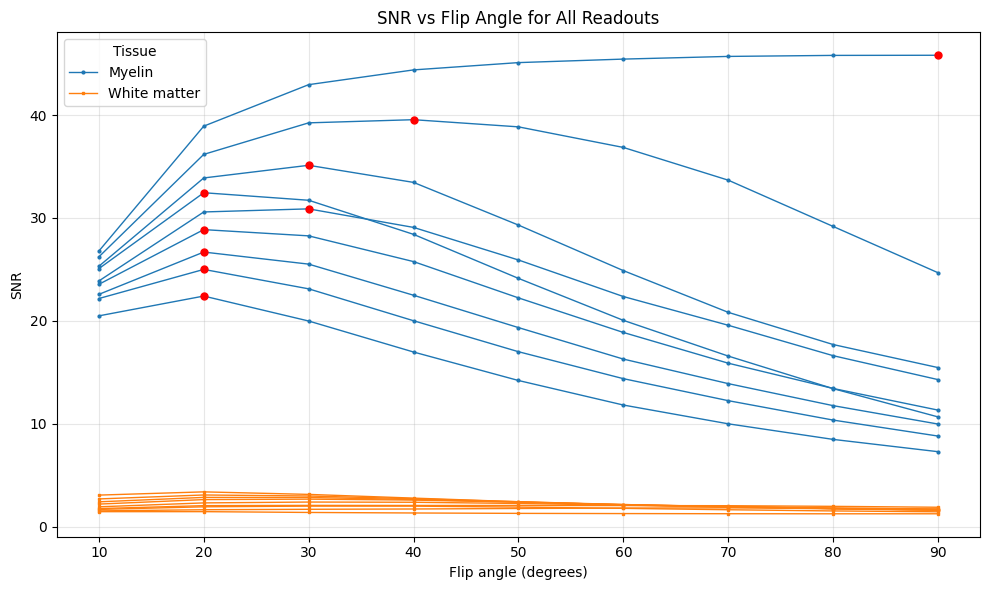

In [25]:
df = pd.read_csv("cnr_efficiency_table.csv")
df = df[(df["flip_angle"] >= 10) & (df["flip_angle"] <= 90)]

plt.figure(figsize=(10, 6))

for readout, sub in df.groupby("n_readout"):
    sub = sub.sort_values("flip_angle")

    # Myelin
    plt.plot(
        sub["flip_angle"],
        sub["snr_myelin"],
        color="tab:blue",
        marker="o",
        markersize=2,
        linewidth = 1,
        label="Myelin" if readout == df["n_readout"].min() else None,
    )

    # White matter
    plt.plot(
        sub["flip_angle"],
        sub["snr_wm"],
        color="tab:orange",
        marker="s",
        markersize=2,
        linestyle="-",
        linewidth = 1,
        label="White matter" if readout == df["n_readout"].min() else None,
    )


    idx_max_myelin = sub["snr_myelin"].idxmax()
    plt.scatter(
        df.loc[idx_max_myelin, "flip_angle"],
        df.loc[idx_max_myelin, "snr_myelin"],
        color="red",
        s=25,
        zorder=5
    )

 

plt.xlabel("Flip angle (degrees)")
plt.ylabel("SNR")
plt.title("SNR vs Flip Angle for All Readouts")
plt.xticks(sorted(df["flip_angle"].unique()))
plt.grid(alpha=0.3)
plt.legend(title="Tissue")
plt.tight_layout()
plt.show()

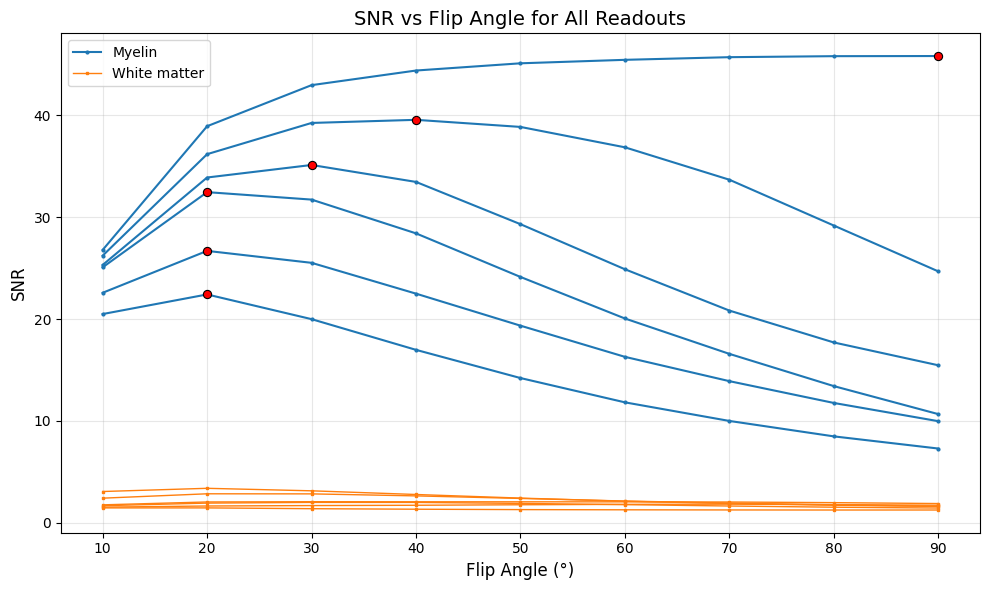

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv("cnr_efficiency_table.csv")

# Filter flip angles and remove readouts 13 and 20
df = df[
    (df["flip_angle"] >= 10) &
    (df["flip_angle"] <= 90) &
    (~df["n_readout"].isin([15, 20, 30]))
]

plt.figure(figsize=(10, 6))

for readout, sub in df.groupby("n_readout"):

    sub = sub.sort_values("flip_angle")

    # Myelin curve
    plt.plot(
        sub["flip_angle"],
        sub["snr_myelin"],
        color="tab:blue",
        marker="o",
        markersize=2,
        linewidth=1.5,
        label="Myelin" if readout == df["n_readout"].min() else None,
    )

    # White matter curve
    plt.plot(
        sub["flip_angle"],
        sub["snr_wm"],
        color="tab:orange",
        marker="s",
        markersize=2,
        linewidth=1,
        linestyle="-",
        label="White matter" if readout == df["n_readout"].min() else None,
    )

    # Myelin maximum
    idx_max_myelin = sub["snr_myelin"].idxmax()

    plt.scatter(
        sub.loc[idx_max_myelin, "flip_angle"],
        sub.loc[idx_max_myelin, "snr_myelin"],
        color="red",
        edgecolor="black",
        linewidth=0.8,
        s=35,
        zorder=10,
    )



plt.xlabel("Flip Angle (°)", fontsize=12)
plt.ylabel("SNR", fontsize=12)
plt.title("SNR vs Flip Angle for All Readouts", fontsize=14)

plt.xticks(sorted(df["flip_angle"].unique()))
plt.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()

plt.savefig(
    "SNR_vs_FlipAngle_AllReadouts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

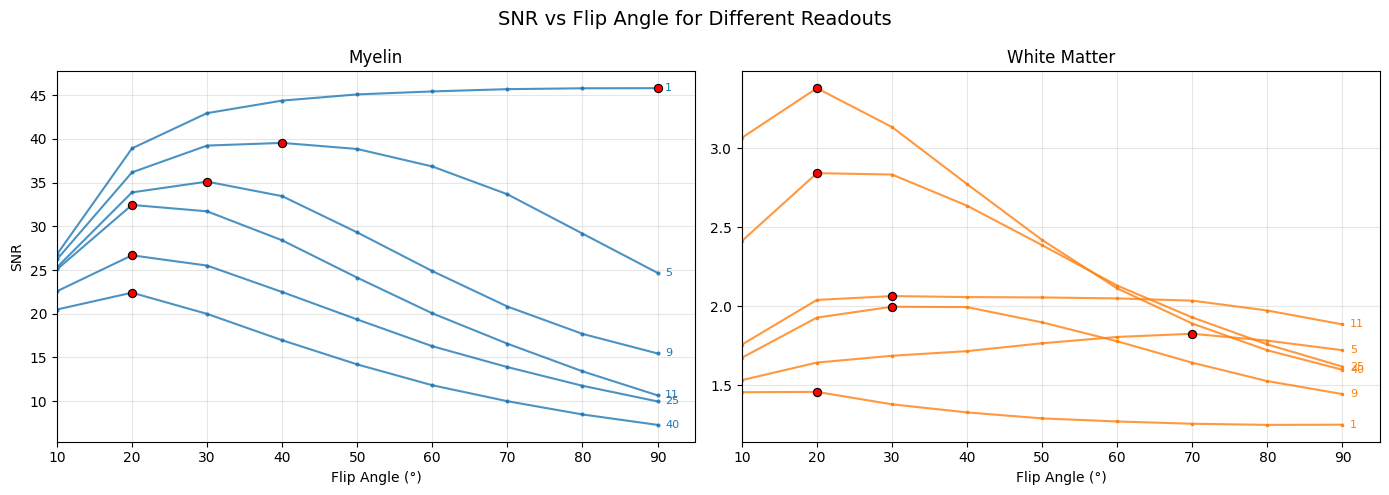

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv("cnr_efficiency_table.csv")

# Filter flip angles and remove readouts
df = df[
    (df["flip_angle"] >= 10) &
    (df["flip_angle"] <= 90) &
    (~df["n_readout"].isin([15, 20, 30]))
]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharex=True,
    sharey=False
)

for readout, sub in df.groupby("n_readout"):

    sub = sub.sort_values("flip_angle")

    # Myelin panel
    ax1.plot(
        sub["flip_angle"],
        sub["snr_myelin"],
        color="tab:blue",
        marker="o",
        markersize=2,
        linewidth=1.5,
        alpha=0.8
    )

    idx_max_myelin = sub["snr_myelin"].idxmax()

    ax1.scatter(
        sub.loc[idx_max_myelin, "flip_angle"],
        sub.loc[idx_max_myelin, "snr_myelin"],
        color="red",
        edgecolor="black",
        linewidth=0.8,
        s=35,
        zorder=10,
    )

    # Add readout number to the right of last Myelin point
    ax1.text(
        sub["flip_angle"].iloc[-1] + 1,
        sub["snr_myelin"].iloc[-1],
        str(readout),
        fontsize=8,
        color="tab:blue",
        va="center"
    )

    # White Matter panel
    ax2.plot(
        sub["flip_angle"],
        sub["snr_wm"],
        color="tab:orange",
        marker="s",
        markersize=2,
        linewidth=1.5,
        alpha=0.8
    )

    idx_max_wm = sub["snr_wm"].idxmax()

    ax2.scatter(
        sub.loc[idx_max_wm, "flip_angle"],
        sub.loc[idx_max_wm, "snr_wm"],
        color="red",
        edgecolor="black",
        linewidth=0.8,
        s=35,
        zorder=10,
    )

    # Add readout number to the right of last WM point
    ax2.text(
        sub["flip_angle"].iloc[-1] + 1,
        sub["snr_wm"].iloc[-1],
        str(readout),
        fontsize=8,
        color="tab:orange",
        va="center"
    )

# Formatting
ax1.set_title("Myelin")
ax2.set_title("White Matter")

ax1.set_xlabel("Flip Angle (°)")
ax2.set_xlabel("Flip Angle (°)")
ax1.set_ylabel("SNR")

for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(df["flip_angle"].unique()))
    ax.set_xlim(10, 95)  # gives space for readout labels

plt.suptitle(
    "SNR vs Flip Angle for Different Readouts",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "SNR_vs_FlipAngle_Myelin_WM_side_by_side.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

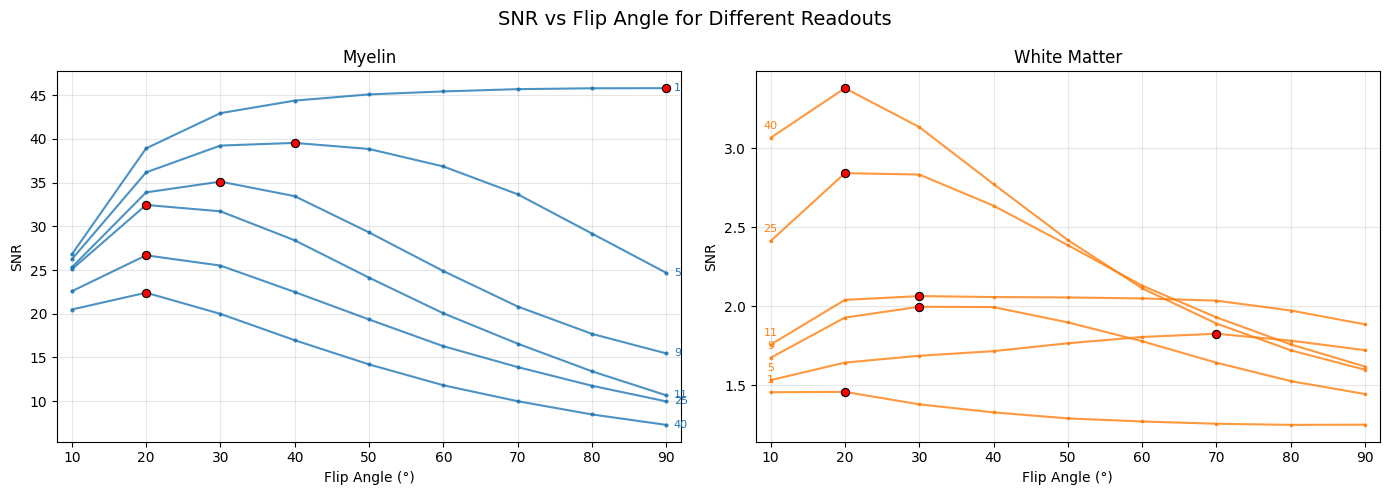

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv("cnr_efficiency_table.csv")

# Filter flip angles and remove readouts
df = df[
    (df["flip_angle"] >= 10) &
    (df["flip_angle"] <= 90) &
    (~df["n_readout"].isin([15, 20, 30]))
]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharex=True,
    sharey=False
)

for readout, sub in df.groupby("n_readout"):

    sub = sub.sort_values("flip_angle")

    # -------------------
    # Myelin panel
    # -------------------
    ax1.plot(
        sub["flip_angle"],
        sub["snr_myelin"],
        color="tab:blue",
        marker="o",
        markersize=2,
        linewidth=1.5,
        alpha=0.8
    )

    idx_max_myelin = sub["snr_myelin"].idxmax()

    ax1.scatter(
        sub.loc[idx_max_myelin, "flip_angle"],
        sub.loc[idx_max_myelin, "snr_myelin"],
        color="red",
        edgecolor="black",
        linewidth=0.8,
        s=35,
        zorder=10,
    )

    # Myelin: label readout number to the right of the last point
    ax1.text(
        sub["flip_angle"].iloc[-1] + 1,
        sub["snr_myelin"].iloc[-1],
        str(readout),
        fontsize=8,
        color="tab:blue",
        va="center"
    )

    # -------------------
    # White Matter panel
    # -------------------
    ax2.plot(
        sub["flip_angle"],
        sub["snr_wm"],
        color="tab:orange",
        marker="s",
        markersize=2,
        linewidth=1.5,
        alpha=0.8
    )

    idx_max_wm = sub["snr_wm"].idxmax()

    ax2.scatter(
        sub.loc[idx_max_wm, "flip_angle"],
        sub.loc[idx_max_wm, "snr_wm"],
        color="red",
        edgecolor="black",
        linewidth=0.8,
        s=35,
        zorder=10,
    )

    # White Matter: label readout number above the first point
    ax2.annotate(
        str(readout),
        xy=(
            sub["flip_angle"].iloc[0],
            sub["snr_wm"].iloc[0]
        ),
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=8,
        color="tab:orange",
        ha="center",
        va="bottom"
    )

# Formatting
ax1.set_title("Myelin")
ax2.set_title("White Matter")

ax1.set_xlabel("Flip Angle (°)")
ax2.set_xlabel("Flip Angle (°)")

ax1.set_ylabel("SNR")
ax2.set_ylabel("SNR")

for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(df["flip_angle"].unique()))

# Give space for Myelin right-side labels
ax1.set_xlim(10, 95)

# WM labels are at first point, so no need for large right margin
ax2.set_xlim(8, 92)

plt.suptitle(
    "SNR vs Flip Angle for Different Readouts",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "SNR_vs_FlipAngle_Myelin_WM_side_by_side.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()